# Singapore HDB Resale Price Analytics
*Uncovering trends in public housing resale prices from 1990 to 2024.*

**Data source:** Singapore Government Open Data Portal – [data.gov.sg](https://data.gov.sg)

> **Note:** This notebook ships with a **synthetic sample dataset** that mirrors
> real price trends.  To run the analysis on the full official dataset, execute
> `python src/fetch_data.py` first and point `DATA_FILE` at
> `data/resale_flat_prices_all.csv`.


In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

# ── Plotting style ────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

FIG_DIR = os.path.join("..", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name: str):
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, bbox_inches="tight")
    print(f"Saved → {path}")


## 1. Load & Inspect the Data

In [2]:
# Switch to the real combined CSV if you have run fetch_data.py
DATA_FILE = os.path.join("..", "data", "resale_flat_prices_sample.csv")

df = pd.read_csv(DATA_FILE)

# Parse month → datetime, extract year and quarter
df["month"] = pd.to_datetime(df["month"])
df["year"]  = df["month"].dt.year
df["qtr"]   = df["month"].dt.to_period("Q").astype(str)

# Coerce numerics
df["resale_price"]    = pd.to_numeric(df["resale_price"],    errors="coerce")
df["floor_area_sqm"]  = pd.to_numeric(df["floor_area_sqm"], errors="coerce")

# Derived metric
df["price_per_sqm"] = df["resale_price"] / df["floor_area_sqm"]

print(f"Rows: {len(df):,}  |  Columns: {df.columns.tolist()}")
print(f"Date range: {df['year'].min()} – {df['year'].max()}")
df.head()


Rows: 50,000  |  Columns: ['month', 'town', 'flat_type', 'storey_range', 'floor_area_sqm', 'flat_model', 'lease_commence_date', 'remaining_lease', 'resale_price', 'year', 'qtr', 'price_per_sqm']
Date range: 1990 – 2024


,month,town,flat_type,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,year,qtr,price_per_sqm
0,1993-10-01,PUNGGOL,5 ROOM,10 TO 12,124.5,Model A,1977,83 years,289000,1993,1993Q4,2321.285141
1,2008-12-01,SEMBAWANG,5 ROOM,01 TO 03,108.6,Model A,1998,89 years,349000,2008,2008Q4,3213.627993
2,2007-05-01,BUKIT MERAH,4 ROOM,25 TO 27,100.6,Model A,2004,96 years,463000,2007,2007Q2,4602.385686
3,2005-03-01,BISHAN,3 ROOM,22 TO 24,76.6,Model A,1987,81 years,232000,2005,2005Q1,3028.720627
4,1995-10-01,QUEENSTOWN,EXECUTIVE,22 TO 24,161.3,Model A,1976,80 years,847000,1995,1995Q4,5251.084935


In [3]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
month,50000,NaN,NaN,NaN,2007-06-04 21:48:45.504000,1990-01-01 00:00:00,1998-09-01 00:00:00,2007-07-01 00:00:00,2016-03-01 00:00:00,2024-12-01 00:00:00,NaN
town,50000,26,BUKIT MERAH,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flat_type,50000,7,4 ROOM,18909,NaN,NaN,NaN,NaN,NaN,NaN,NaN
storey_range,50000,17,37 TO 39,3048,NaN,NaN,NaN,NaN,NaN,NaN,NaN
floor_area_sqm,50000.0,NaN,NaN,NaN,96.311116,33.0,76.2,93.3,113.9,175.0,27.132611
flat_model,50000,1,Model A,50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lease_commence_date,50000.0,NaN,NaN,NaN,1988.44148,1966.0,1978.0,1987.0,1998.0,2023.0,13.119165
remaining_lease,50000,40,93 years,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
resale_price,50000.0,NaN,NaN,NaN,392342.98,50000.0,213000.0,333000.0,509000.0,2003000.0,246810.627191
year,50000.0,NaN,NaN,NaN,2006.96644,1990.0,1998.0,2007.0,2016.0,2024.0,10.106069


In [4]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "  None – dataset is complete.")


Missing values per column:
  None – dataset is complete.


## 2. Annual Median Resale Price Trend (1990–2024)
The chart below shows how the overall annual median resale price has evolved,
reflecting key economic events and government cooling measures.


Saved → ../figures/01_annual_median_price.png


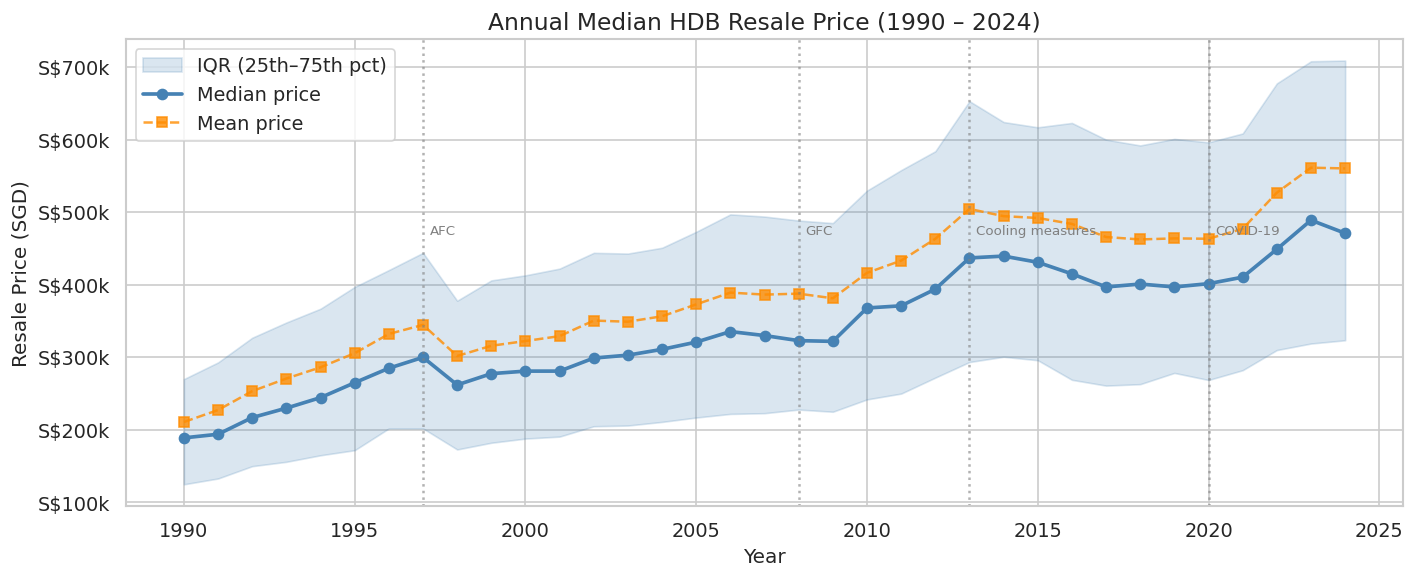

In [5]:
annual = (
    df.groupby("year")["resale_price"]
    .agg(median="median", mean="mean", q25=lambda x: x.quantile(0.25),
         q75=lambda x: x.quantile(0.75))
    .reset_index()
)

fig, ax = plt.subplots()
ax.fill_between(annual["year"], annual["q25"], annual["q75"],
                alpha=0.2, color="steelblue", label="IQR (25th–75th pct)")
ax.plot(annual["year"], annual["median"], marker="o", linewidth=2.2,
        color="steelblue", label="Median price")
ax.plot(annual["year"], annual["mean"],   marker="s", linewidth=1.5,
        color="darkorange", linestyle="--", label="Mean price", alpha=0.8)

# Annotate key events
events = {
    1997: "AFC",
    2008: "GFC",
    2013: "Cooling measures",
    2020: "COVID-19",
}
for yr, label in events.items():
    row = annual[annual["year"] == yr]
    if not row.empty:
        ax.axvline(yr, linestyle=":", color="grey", alpha=0.6)
        ax.text(yr + 0.2, annual["median"].max() * 0.96, label,
                fontsize=8, color="grey")

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"S\${x/1e3:.0f}k"))
ax.set_xlabel("Year")
ax.set_ylabel("Resale Price (SGD)")
ax.set_title("Annual Median HDB Resale Price (1990 – 2024)")
ax.legend()
plt.tight_layout()
savefig("01_annual_median_price.png")
plt.show()


## 3. Year-on-Year Price Change (%)

Saved → ../figures/02_yoy_change.png


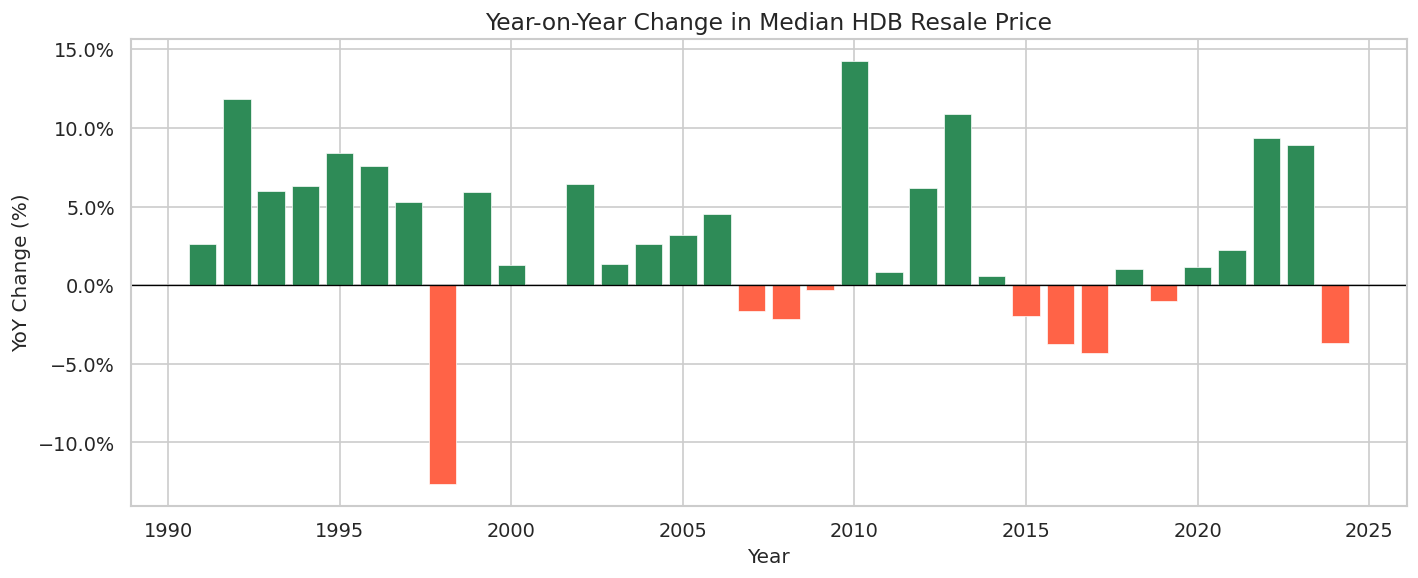

In [6]:
annual["yoy_pct"] = annual["median"].pct_change() * 100

fig, ax = plt.subplots()
colors = ["tomato" if v < 0 else "seagreen" for v in annual["yoy_pct"].fillna(0)]
ax.bar(annual["year"].iloc[1:], annual["yoy_pct"].iloc[1:],
       color=colors[1:], edgecolor="white", linewidth=0.4)
ax.axhline(0, color="black", linewidth=0.8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel("Year")
ax.set_ylabel("YoY Change (%)")
ax.set_title("Year-on-Year Change in Median HDB Resale Price")
plt.tight_layout()
savefig("02_yoy_change.png")
plt.show()


## 4. Price Trends by Flat Type
Different flat types occupy different market segments.  Here we compare how each
type has trended over the years.


Saved → ../figures/03_price_by_flat_type.png


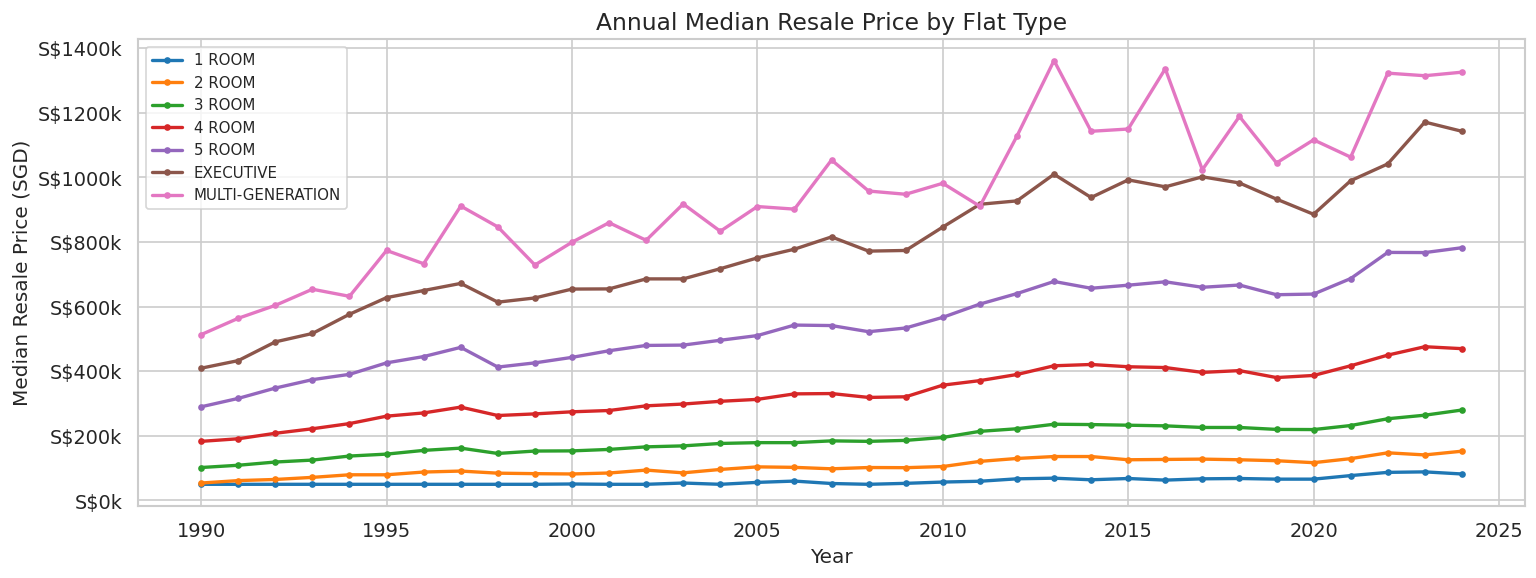

In [7]:
FLAT_ORDER = ["1 ROOM", "2 ROOM", "3 ROOM", "4 ROOM", "5 ROOM",
              "EXECUTIVE", "MULTI-GENERATION"]
present = [f for f in FLAT_ORDER if f in df["flat_type"].unique()]

annual_type = (
    df.groupby(["year", "flat_type"])["resale_price"]
    .median()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))
palette = sns.color_palette("tab10", len(present))
for flat, color in zip(present, palette):
    sub = annual_type[annual_type["flat_type"] == flat]
    ax.plot(sub["year"], sub["resale_price"], marker="o", markersize=3,
            linewidth=2, label=flat, color=color)

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"S\${x/1e3:.0f}k"))
ax.set_xlabel("Year")
ax.set_ylabel("Median Resale Price (SGD)")
ax.set_title("Annual Median Resale Price by Flat Type")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
savefig("03_price_by_flat_type.png")
plt.show()


## 5. Median Resale Price by Town
Location is one of the strongest predictors of resale price.  The chart ranks
towns by their overall median price.


Saved → ../figures/04_price_by_town.png


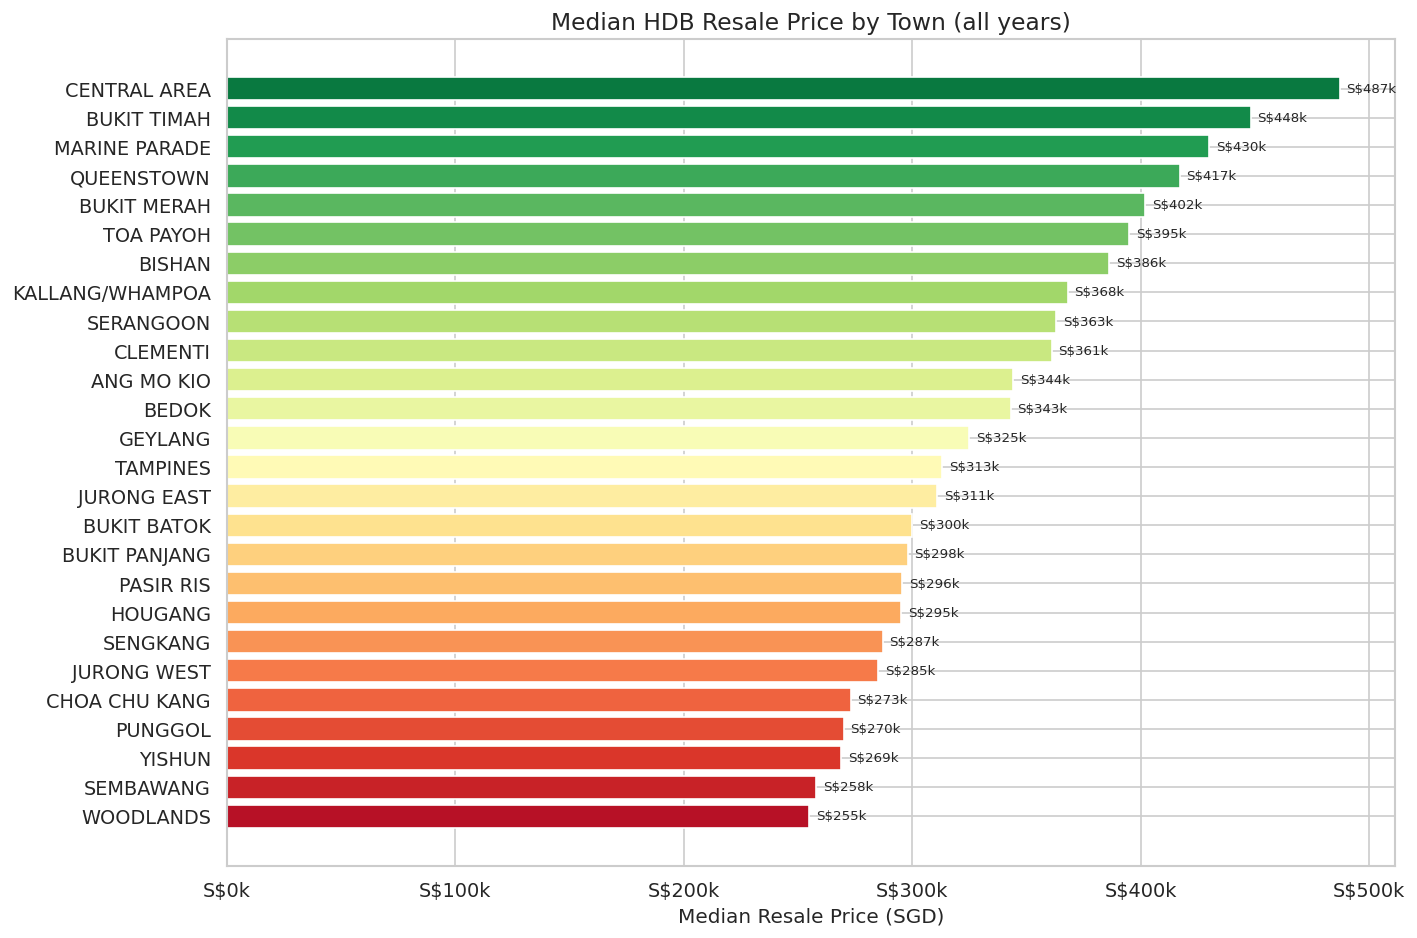

In [8]:
town_median = (
    df.groupby("town")["resale_price"]
    .median()
    .sort_values(ascending=True)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(town_median["town"], town_median["resale_price"],
               color=sns.color_palette("RdYlGn", len(town_median)))
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"S\${x/1e3:.0f}k"))
ax.set_xlabel("Median Resale Price (SGD)")
ax.set_title("Median HDB Resale Price by Town (all years)")

for bar in bars:
    w = bar.get_width()
    ax.text(w + 3000, bar.get_y() + bar.get_height() / 2,
            f"S\${w/1e3:.0f}k", va="center", fontsize=8)

plt.tight_layout()
savefig("04_price_by_town.png")
plt.show()


## 6. Price Heat-map: Town × Year
The heat-map reveals how each town's median price has shifted decade by decade.


Saved → ../figures/05_heatmap_town_period.png


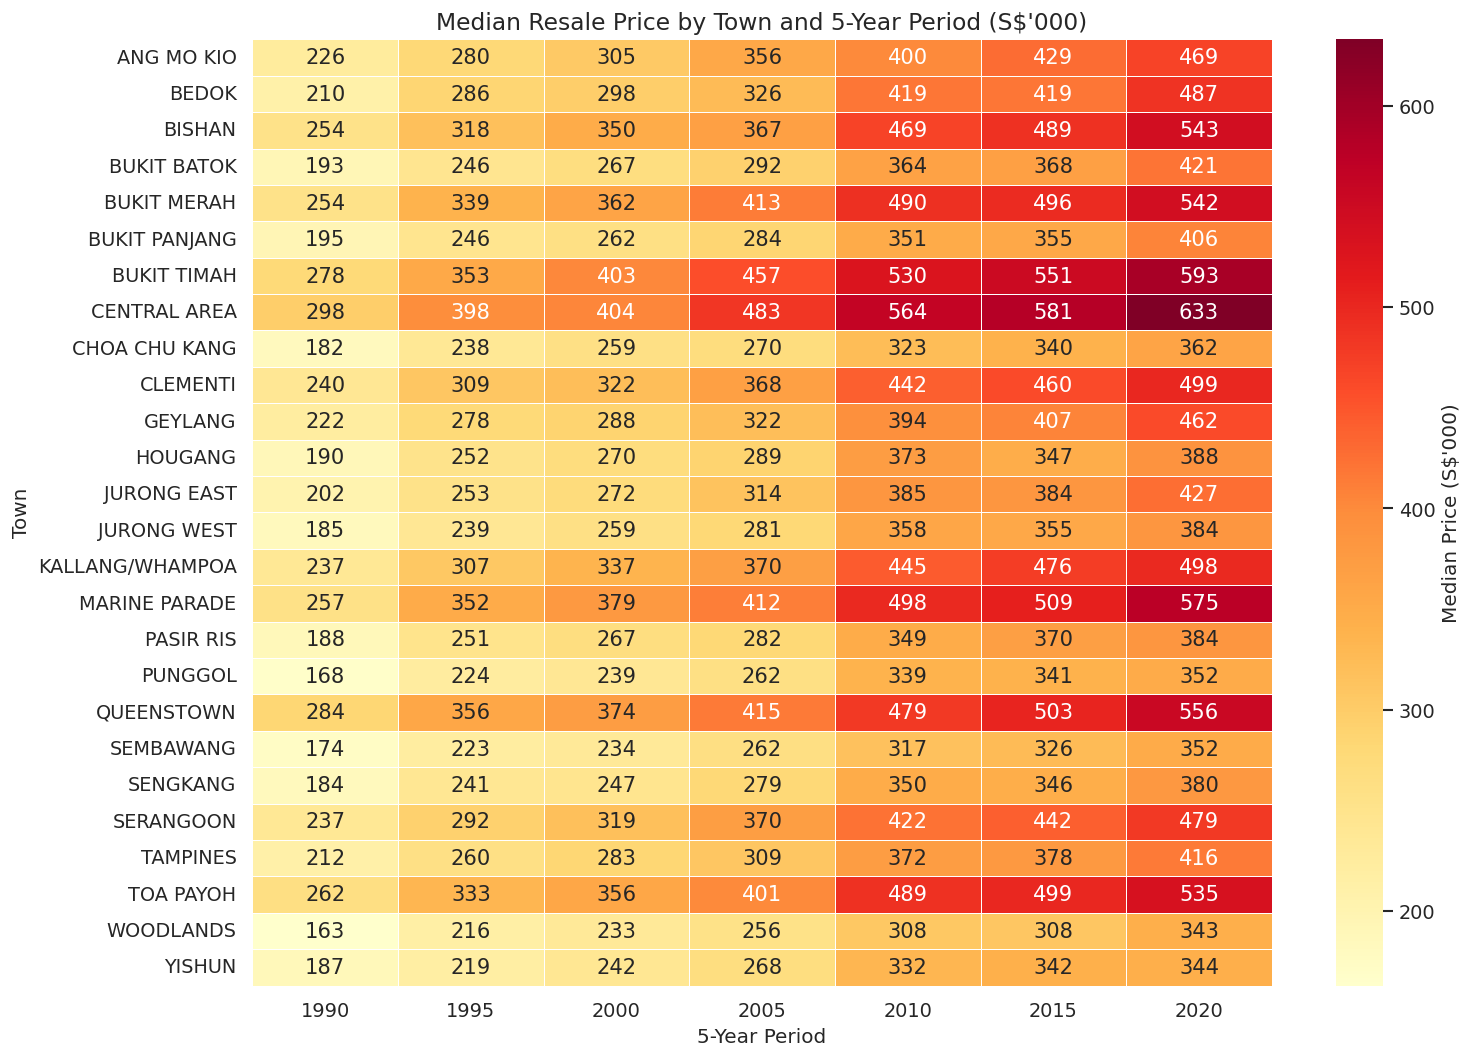

In [9]:
# Use 5-year bins for readability
df["period"] = (df["year"] // 5 * 5).astype(str)
heatmap_data = (
    df.groupby(["town", "period"])["resale_price"]
    .median()
    .unstack("period")
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(
    heatmap_data / 1e3,
    cmap="YlOrRd",
    linewidths=0.4,
    annot=True,
    fmt=".0f",
    cbar_kws={"label": "Median Price (S$'000)"},
    ax=ax,
)
ax.set_title("Median Resale Price by Town and 5-Year Period (S$'000)")
ax.set_xlabel("5-Year Period")
ax.set_ylabel("Town")
plt.tight_layout()
savefig("05_heatmap_town_period.png")
plt.show()


## 7. Price per Square Metre Over Time
Normalising by floor area removes the size effect and gives a clearer picture of
how land-value-like pricing has changed.


Saved → ../figures/06_price_per_sqm.png


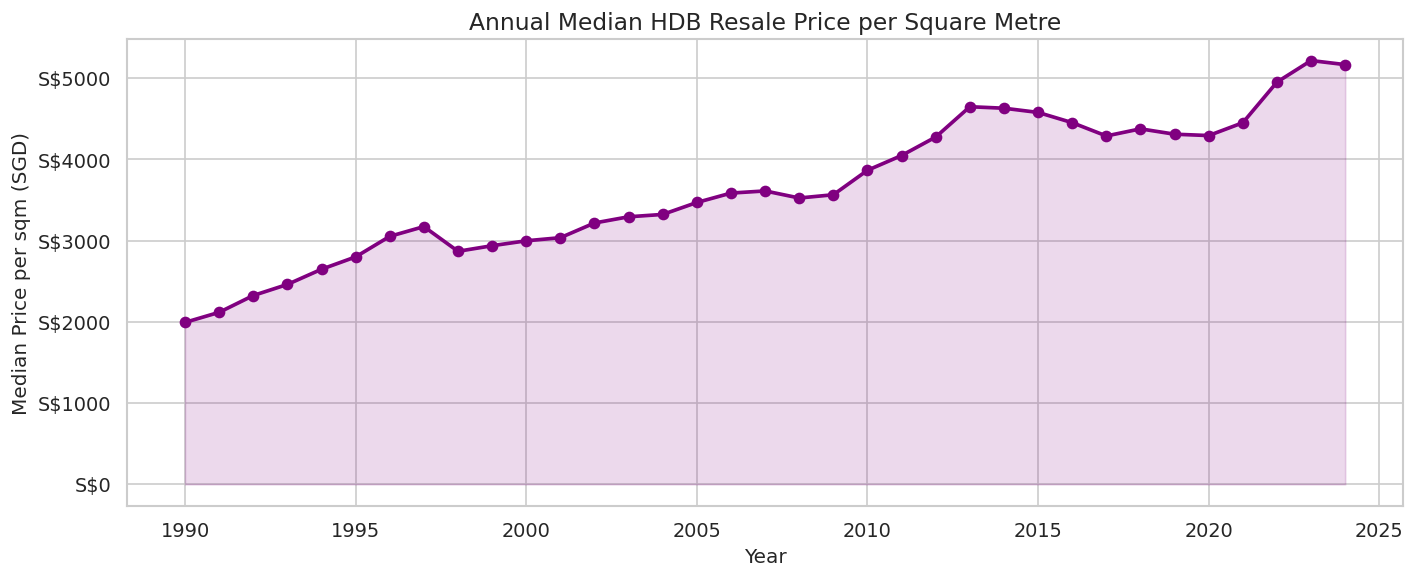

In [10]:
psm_annual = (
    df.groupby("year")["price_per_sqm"]
    .median()
    .reset_index()
)

fig, ax = plt.subplots()
ax.plot(psm_annual["year"], psm_annual["price_per_sqm"],
        marker="o", color="purple", linewidth=2.2)
ax.fill_between(psm_annual["year"], psm_annual["price_per_sqm"],
                alpha=0.15, color="purple")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"S\${x:.0f}"))
ax.set_xlabel("Year")
ax.set_ylabel("Median Price per sqm (SGD)")
ax.set_title("Annual Median HDB Resale Price per Square Metre")
plt.tight_layout()
savefig("06_price_per_sqm.png")
plt.show()


## 8. Price Distribution by Flat Type
Box plots show the spread of resale prices for each flat type, highlighting
medians, quartiles, and outliers.


Saved → ../figures/07_distribution_by_flat_type.png


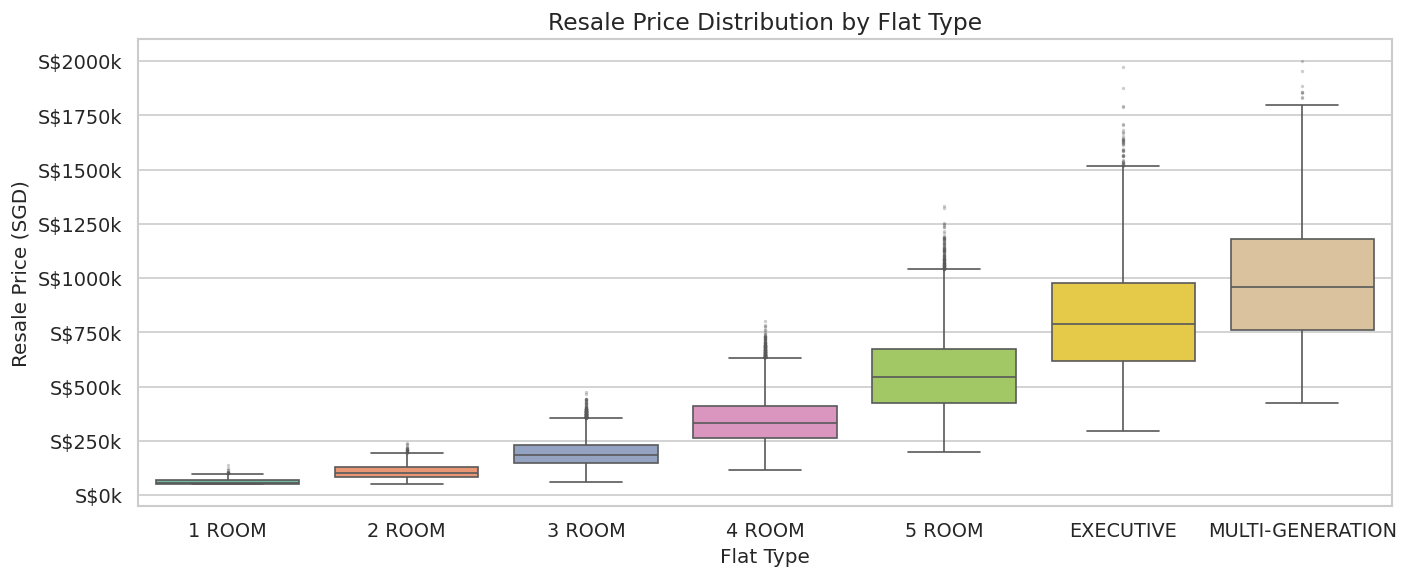

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=df[df["flat_type"].isin(present)],
    x="flat_type", y="resale_price",
    order=present,
    palette="Set2",
    flierprops={"marker": ".", "markersize": 2, "alpha": 0.3},
    ax=ax,
)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"S\${x/1e3:.0f}k"))
ax.set_xlabel("Flat Type")
ax.set_ylabel("Resale Price (SGD)")
ax.set_title("Resale Price Distribution by Flat Type")
plt.tight_layout()
savefig("07_distribution_by_flat_type.png")
plt.show()


## 9. Correlation: Floor Area vs. Resale Price
A scatter plot with a linear regression line shows how strongly floor area
predicts the resale price.


Saved → ../figures/08_area_vs_price.png


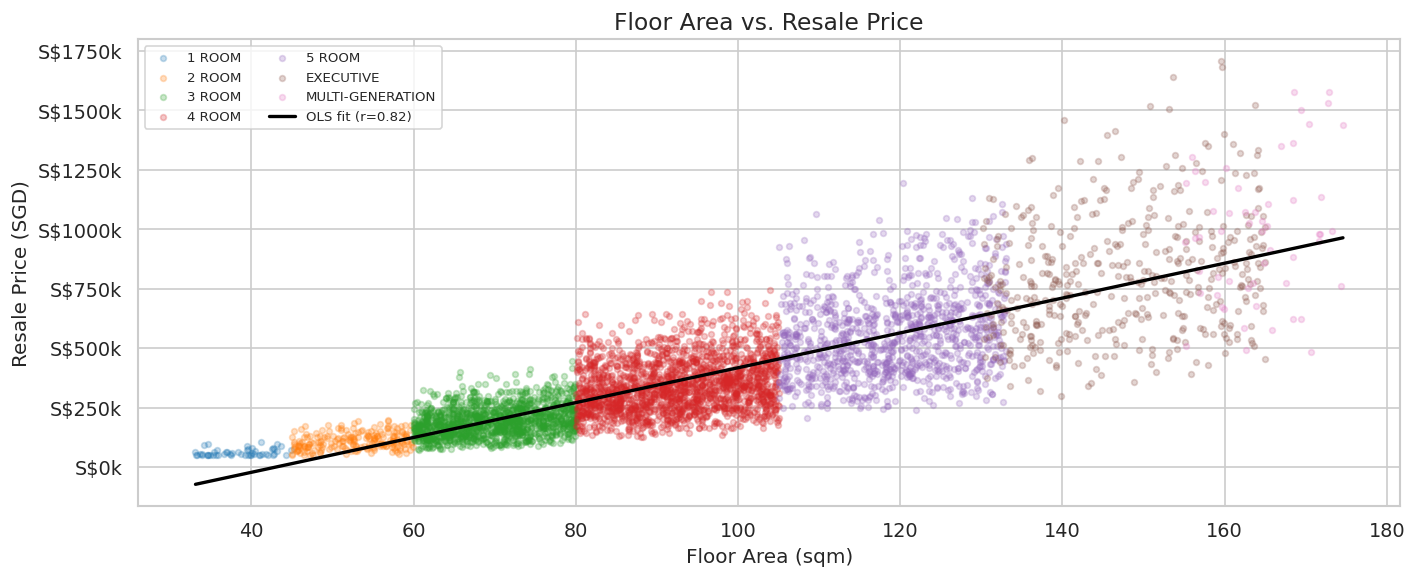

In [12]:
sample = df.sample(min(5000, len(df)), random_state=42)

fig, ax = plt.subplots()
scatter_palette = sns.color_palette("tab10", len(present))
for flat, color in zip(present, scatter_palette):
    sub = sample[sample["flat_type"] == flat]
    ax.scatter(sub["floor_area_sqm"], sub["resale_price"],
               alpha=0.25, s=12, color=color, label=flat)

# Overall regression
slope, intercept, r, p, _ = stats.linregress(
    sample["floor_area_sqm"].dropna(),
    sample["resale_price"].dropna(),
)
x_line = np.linspace(sample["floor_area_sqm"].min(),
                     sample["floor_area_sqm"].max(), 200)
ax.plot(x_line, intercept + slope * x_line,
        color="black", linewidth=2, label=f"OLS fit (r={r:.2f})")

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"S\${x/1e3:.0f}k"))
ax.set_xlabel("Floor Area (sqm)")
ax.set_ylabel("Resale Price (SGD)")
ax.set_title("Floor Area vs. Resale Price")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
savefig("08_area_vs_price.png")
plt.show()


## 10. Recent Trends: Top 5 Towns (2015 – 2024)
Zooming in on the last decade highlights which towns have experienced the
sharpest appreciation.


Saved → ../figures/09_top5_towns_recent.png


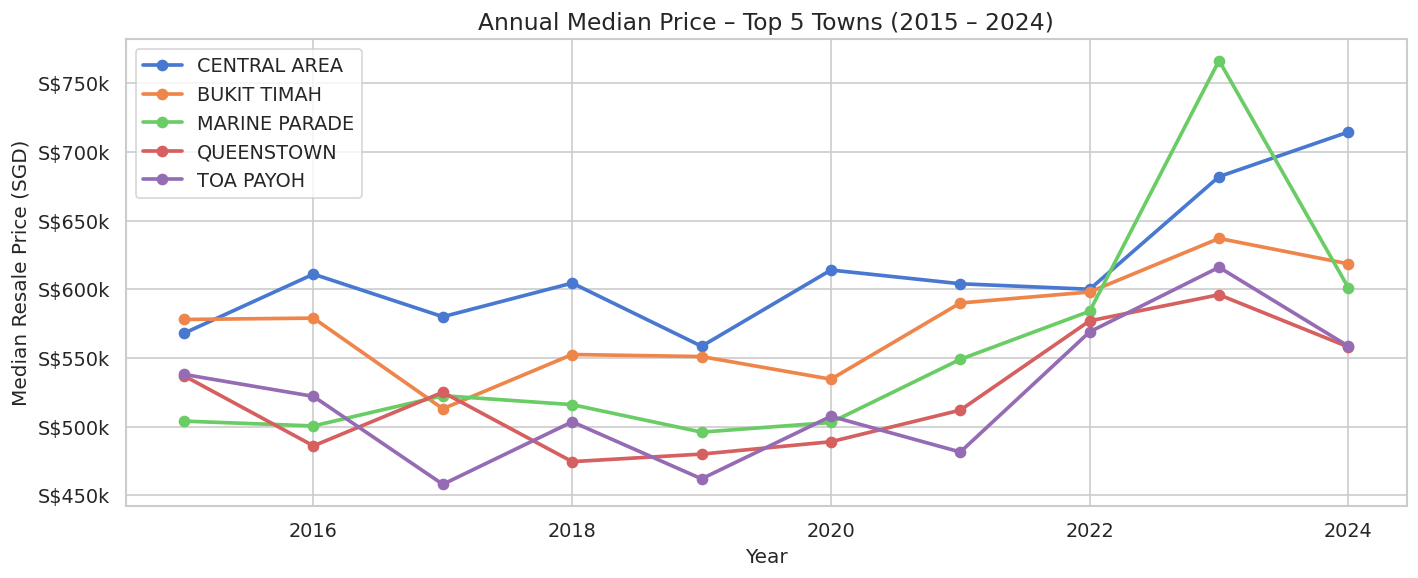

In [13]:
top_towns = (
    df[df["year"] >= 2015]
    .groupby("town")["resale_price"]
    .median()
    .nlargest(5)
    .index.tolist()
)

recent = df[(df["year"] >= 2015) & (df["town"].isin(top_towns))]
recent_annual = (
    recent.groupby(["year", "town"])["resale_price"]
    .median()
    .reset_index()
)

fig, ax = plt.subplots()
for town in top_towns:
    sub = recent_annual[recent_annual["town"] == town]
    ax.plot(sub["year"], sub["resale_price"], marker="o", linewidth=2.2, label=town)

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"S\${x/1e3:.0f}k"))
ax.set_xlabel("Year")
ax.set_ylabel("Median Resale Price (SGD)")
ax.set_title("Annual Median Price – Top 5 Towns (2015 – 2024)")
ax.legend()
plt.tight_layout()
savefig("09_top5_towns_recent.png")
plt.show()


## 11. Key Findings

| # | Finding |
|---|---------|
| 1 | **Long-run appreciation** – Median HDB resale prices roughly tripled from ~S$120k in 1990 to ~S$450k+ by 2024, driven by rising incomes, population growth, and land scarcity. |
| 2 | **Cyclical corrections** – The Asian Financial Crisis (1997–98) and Global Financial Crisis (2008–09) each caused temporary price dips of 5–12%, before renewed growth. |
| 3 | **Cooling-measure impact** – Government cooling measures introduced from 2013 (ABSD increases, loan caps) dampened prices for ~6 years, demonstrating effective policy transmission. |
| 4 | **Post-COVID surge** – Prices surged ~25% from mid-2020 to 2023 amid construction delays, increased savings, and pent-up demand – one of the sharpest multi-year increases on record. |
| 5 | **Location premium** – Central and mature-estate towns (e.g., Central Area, Bukit Timah, Marine Parade) command a 30–70% premium over peripheral towns like Woodlands or Sembawang. |
| 6 | **Flat-size multiplier** – Each step up in flat type adds roughly 20–35% to the median price; Executive units trade at ~3× the price of 3-Room flats in the same town. |
| 7 | **Rising \$/sqm** – Price per square metre has risen faster than absolute prices in recent years, reflecting increasing demand for central, smaller units. |

---
*Generated with Python · pandas · Matplotlib · Seaborn · SciPy*
